# ImageNet Feature Selection Benchmark

Ноутбук для classifier-only benchmark, максимально близкого к секции `5.2 Feature Selection Study` из *How Important Is a Neuron?*. Он использует `ImageNet val`, берёт `4` задачи по `5` классов, использует `30 train / 20 eval` изображений на класс и сравнивает `IG`, `NAA` и `Cheap-IG+[0,0.1]/k8000/zero` через linear probe на выбранных фильтрах.

Текущая постановка:
- dataset: `imagenet_val`
- target: `GT class logit`
- layer: `model.6`
- unit: `filter/channel`
- class aggregation: `positive_mean`
- selection rule: `max_over_classes`
- probe: `StandardScaler + LogisticRegression`
- tasks: `dogs_related`, `cats_related`, `random_a`, `random_b`


## Импорты

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from modules.imagenet_feature_selection_benchmark import (
    benchmark_imagenet_feature_selection,
    collect_imagenet_val_image_paths,
    default_classifier_method_specs,
    default_imagenet_feature_selection_tasks,
    render_imagenet_feature_selection_report,
)


## Параметры

In [2]:
IMAGENET_VAL_ROOT = Path("imagenet_val")
LAYER_NAME = "model.6"
N_STEPS = 128
TRAIN_PER_CLASS = 30
EVAL_PER_CLASS = 20
K_VALUES = [4, 8, 16, 32, 64]
CHANNEL_AGGREGATION = "positive_mean"
SELECTION_RULE = "max_over_classes"
RANDOM_SEED = 0
CLEAR_EVERY = 8
FD_EPS = 1e-3

CACHE_ROOT = Path("output/imagenet_feature_selection_cache")
OUTPUT_DIR = Path("output/imagenet_feature_selection_benchmark")
REFRESH_CORE = False
REFRESH_METHODS = False


## Датасет

In [3]:
IMAGE_PATHS = collect_imagenet_val_image_paths(IMAGENET_VAL_ROOT)
len(IMAGE_PATHS), IMAGE_PATHS[:3]


(50000,
 ['imagenet_val/n01440764/ILSVRC2012_val_00000293.JPEG',
  'imagenet_val/n01440764/ILSVRC2012_val_00002138.JPEG',
  'imagenet_val/n01440764/ILSVRC2012_val_00003014.JPEG'])

## Tasks

In [4]:
CLASS_TASKS = default_imagenet_feature_selection_tasks(IMAGENET_VAL_ROOT, random_seed=RANDOM_SEED)
CLASS_TASKS


[{'name': 'dogs_related',
  'wnids': ['n02085620', 'n02085782', 'n02085936', 'n02086079', 'n02086240']},
 {'name': 'cats_related',
  'wnids': ['n02123045', 'n02123159', 'n02123394', 'n02123597', 'n02124075']},
 {'name': 'random_a',
  'wnids': ['n04372370', 'n04275548', 'n03706229', 'n03109150', 'n02114548']},
 {'name': 'random_b',
  'wnids': ['n01682714', 'n01560419', 'n02231487', 'n02092339', 'n01773797']}]

## Методы

In [5]:
METHOD_SPECS = default_classifier_method_specs()
METHOD_SPECS


[{'kind': 'ig', 'segment_start': 0.0, 'segment_end': 1.0, 'name': 'IG'},
 {'kind': 'naa', 'segment_start': 0.0, 'segment_end': 1.0, 'name': 'NAA'},
 {'kind': 'cheap_ig',
  'segment_start': 0.0,
  'segment_end': 0.1,
  'selection_mode': 'positive',
  'selection_top_k': 8000,
  'fill_mode': 'zero',
  'fill_rho': 0.8,
  'name': 'Cheap-IG+[0,0.1]/k8000/zero'}]

## Запуск Benchmark

In [6]:
results = benchmark_imagenet_feature_selection(
    image_paths=IMAGE_PATHS,
    method_specs=METHOD_SPECS,
    class_tasks=CLASS_TASKS,
    layer_name=LAYER_NAME,
    n_steps=N_STEPS,
    train_per_class=TRAIN_PER_CLASS,
    eval_per_class=EVAL_PER_CLASS,
    k_values=K_VALUES,
    channel_aggregation=CHANNEL_AGGREGATION,
    selection_rule=SELECTION_RULE,
    random_seed=RANDOM_SEED,
    cache_root=CACHE_ROOT,
    target_dir=OUTPUT_DIR,
    save_output=True,
    top_n=0,
    fd_eps=FD_EPS,
    clear_every=CLEAR_EVERY,
    refresh_core=REFRESH_CORE,
    refresh_methods=REFRESH_METHODS,
)

print("output_dir:", results["output_dir"])
print("report_path:", results["report_path"])
print("summary_path:", results["summary_path"])


output_dir: /Users/ashentide/PycharmProjects/PaperImplementations/output/imagenet_feature_selection_benchmark
report_path: /Users/ashentide/PycharmProjects/PaperImplementations/output/imagenet_feature_selection_benchmark/imagenet_feature_selection_report.md
summary_path: /Users/ashentide/PycharmProjects/PaperImplementations/output/imagenet_feature_selection_benchmark/imagenet_feature_selection_summary.json


## Перерисовка отчёта

In [7]:
artifacts = render_imagenet_feature_selection_report(results, output_dir=OUTPUT_DIR)
artifacts["report_path"], artifacts["summary_path"]


('output/imagenet_feature_selection_benchmark/imagenet_feature_selection_report.md',
 'output/imagenet_feature_selection_benchmark/imagenet_feature_selection_summary.json')

## Markdown-отчёт

In [8]:
display(Markdown(Path(artifacts["report_path"]).read_text(encoding="utf-8")))


# ImageNet Feature Selection Benchmark

Classifier-only feature-selection benchmark aligned with Sec. 5.2 of *How Important Is a Neuron?*.

## Configuration

- dataset=`imagenet_val`
- layer_name=`model.6`
- n_steps=`128`
- train_per_class=`30`
- eval_per_class=`20`
- k_values=`[4, 8, 16, 32, 64]`
- channel_aggregation=`positive_mean`
- selection_rule=`max_over_classes`
- random_seed=`0`

## Tasks

| Task | WNIDs | Classes |
| --- | --- | --- |
| dogs_related | n02085620, n02085782, n02085936, n02086079, n02086240 | Chihuahua, Japanese_spaniel, Maltese_dog, Pekinese, Shih-Tzu |
| cats_related | n02123045, n02123159, n02123394, n02123597, n02124075 | tabby, tiger_cat, Persian_cat, Siamese_cat, Egyptian_cat |
| random_a | n04372370, n04275548, n03706229, n03109150, n02114548 | switch, spider_web, magnetic_compass, corkscrew, white_wolf |
| random_b | n01682714, n01560419, n02231487, n02092339, n01773797 | American_chameleon, bulbul, walking_stick, Weimaraner, garden_spider |

## Best-k Summary

| Method | Best k | Mean accuracy | Mean macro-F1 |
| --- | ---: | ---: | ---: |
| IG | 64 | 0.7225 | 0.7217 |
| NAA | 64 | 0.7350 | 0.7337 |
| Cheap-IG+[0,0.1]/k8000/zero | 64 | 0.7050 | 0.7022 |

## Mean Accuracy / Macro-F1 by k

| Method | k | Mean accuracy | Std accuracy | Mean macro-F1 | Std macro-F1 |
| --- | ---: | ---: | ---: | ---: | ---: |
| IG | 4 | 0.4550 | 0.0229 | 0.4411 | 0.0267 |
| IG | 8 | 0.5750 | 0.1016 | 0.5723 | 0.1081 |
| IG | 16 | 0.6225 | 0.1443 | 0.6143 | 0.1522 |
| IG | 32 | 0.7050 | 0.1450 | 0.7019 | 0.1492 |
| IG | 64 | 0.7225 | 0.1657 | 0.7217 | 0.1655 |
| NAA | 4 | 0.3775 | 0.0928 | 0.3599 | 0.0976 |
| NAA | 8 | 0.5175 | 0.1066 | 0.5082 | 0.1069 |
| NAA | 16 | 0.6250 | 0.1582 | 0.6203 | 0.1603 |
| NAA | 32 | 0.6850 | 0.1572 | 0.6833 | 0.1597 |
| NAA | 64 | 0.7350 | 0.1582 | 0.7337 | 0.1601 |
| Cheap-IG+[0,0.1]/k8000/zero | 4 | 0.4350 | 0.0427 | 0.4174 | 0.0466 |
| Cheap-IG+[0,0.1]/k8000/zero | 8 | 0.5000 | 0.1332 | 0.4902 | 0.1421 |
| Cheap-IG+[0,0.1]/k8000/zero | 16 | 0.6250 | 0.1464 | 0.6203 | 0.1503 |
| Cheap-IG+[0,0.1]/k8000/zero | 32 | 0.6850 | 0.1629 | 0.6849 | 0.1630 |
| Cheap-IG+[0,0.1]/k8000/zero | 64 | 0.7050 | 0.1727 | 0.7022 | 0.1735 |

![](output/imagenet_feature_selection_benchmark/figures/accuracy_curves.png)

![](output/imagenet_feature_selection_benchmark/figures/macro_f1_curves.png)

![](output/imagenet_feature_selection_benchmark/figures/accuracy_heatmaps.png)

![](output/imagenet_feature_selection_benchmark/figures/macro_f1_heatmaps.png)

![](output/imagenet_feature_selection_benchmark/figures/selected_overlap.png)



## Best-k Summary

In [9]:
best_df = pd.DataFrame(results["summary"]["best_rows"])
best_df


,method_name,best_k,best_accuracy_mean,best_macro_f1_mean
0,IG,64,0.7225,0.721742
1,NAA,64,0.7350,0.733730
2,"Cheap-IG+[0,0.1]/k8000/zero",64,0.7050,0.702201


## Mean Accuracy / Macro-F1 by k

In [10]:
summary_df = pd.DataFrame(results["summary"]["summary_rows"])
summary_df


,method_name,k,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,n_tasks
0,IG,4,0.4550,0.022913,0.441082,0.026684,4
1,IG,8,0.5750,0.101612,0.572321,0.108128,4
2,IG,16,0.6225,0.144287,0.614289,0.152193,4
3,IG,32,0.7050,0.145000,0.701911,0.149228,4
4,IG,64,0.7225,0.165737,0.721742,0.165457,4
5,NAA,4,0.3775,0.092837,0.359928,0.097618,4
6,NAA,8,0.5175,0.106624,0.508217,0.106934,4
7,NAA,16,0.6250,0.158193,0.620299,0.160303,4
8,NAA,32,0.6850,0.157242,0.683274,0.159694,4
9,NAA,64,0.7350,0.158193,0.733730,0.160137,4


## Per-task Accuracy Pivot

In [11]:
rows_df = pd.DataFrame(results["rows"])
accuracy_pivot = rows_df.pivot_table(index=["task_name", "k"], columns="method_name", values="accuracy")
accuracy_pivot


method_name      Cheap-IG+[0,0.1]/k8000/zero    IG   NAA
task_name    k                                          
cats_related 4                          0.41  0.43  0.29
             8                          0.38  0.47  0.35
             16                         0.49  0.50  0.47
             32                         0.52  0.52  0.49
             64                         0.46  0.49  0.51
dogs_related 4                          0.38  0.44  0.28
             8                          0.36  0.48  0.50
             16                         0.50  0.47  0.52
             32                         0.57  0.65  0.59
             64                         0.65  0.68  0.70
random_a     4                          0.46  0.46  0.46
             8                          0.67  0.70  0.61
             16                         0.85  0.82  0.88
             32                         0.94  0.92  0.90
             64                         0.93  0.95  0.95
random_b     4                          0.49  0.49  0.48
             8                          0.59  0.65  0.61
             16                         0.66  0.70  0.63
             32                         0.71  0.73  0.76
             64                         0.78  0.77  0.78

## Per-task Macro-F1 Pivot

In [12]:
macro_f1_pivot = rows_df.pivot_table(index=["task_name", "k"], columns="method_name", values="macro_f1")
macro_f1_pivot


method_name      Cheap-IG+[0,0.1]/k8000/zero        IG       NAA
task_name    k                                                  
cats_related 4                      0.370713  0.400477  0.272841
             8                      0.351337  0.458449  0.341855
             16                     0.471953  0.473614  0.462914
             32                     0.516672  0.507244  0.479378
             64                     0.456884  0.490209  0.504576
dogs_related 4                      0.371878  0.436685  0.253254
             8                      0.352045  0.474683  0.486923
             16                     0.501093  0.465206  0.516252
             32                     0.573338  0.651693  0.595880
             64                     0.648088  0.680794  0.700110
random_a     4                      0.454435  0.454435  0.442984
             8                      0.673137  0.708886  0.603176
             16                     0.849952  0.824957  0.879504
             32                     0.939675  0.920985  0.900937
             64                     0.930954  0.950440  0.949994
random_b     4                      0.472731  0.472731  0.470633
             8                      0.584470  0.647264  0.600913
             16                     0.658367  0.693378  0.622526
             32                     0.709851  0.727722  0.756901
             64                     0.772879  0.765527  0.780240

## Ключевые фигуры

### Mean Accuracy Curves

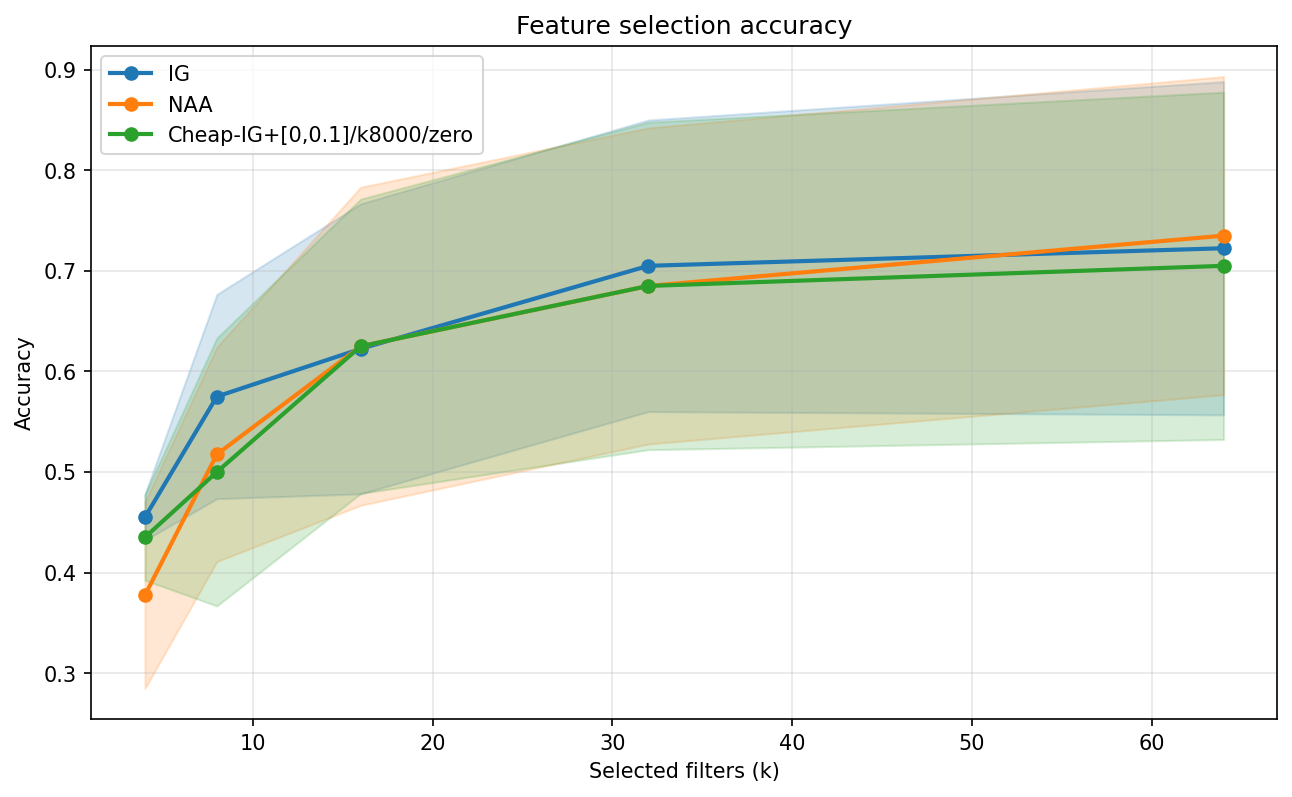

### Mean Macro-F1 Curves

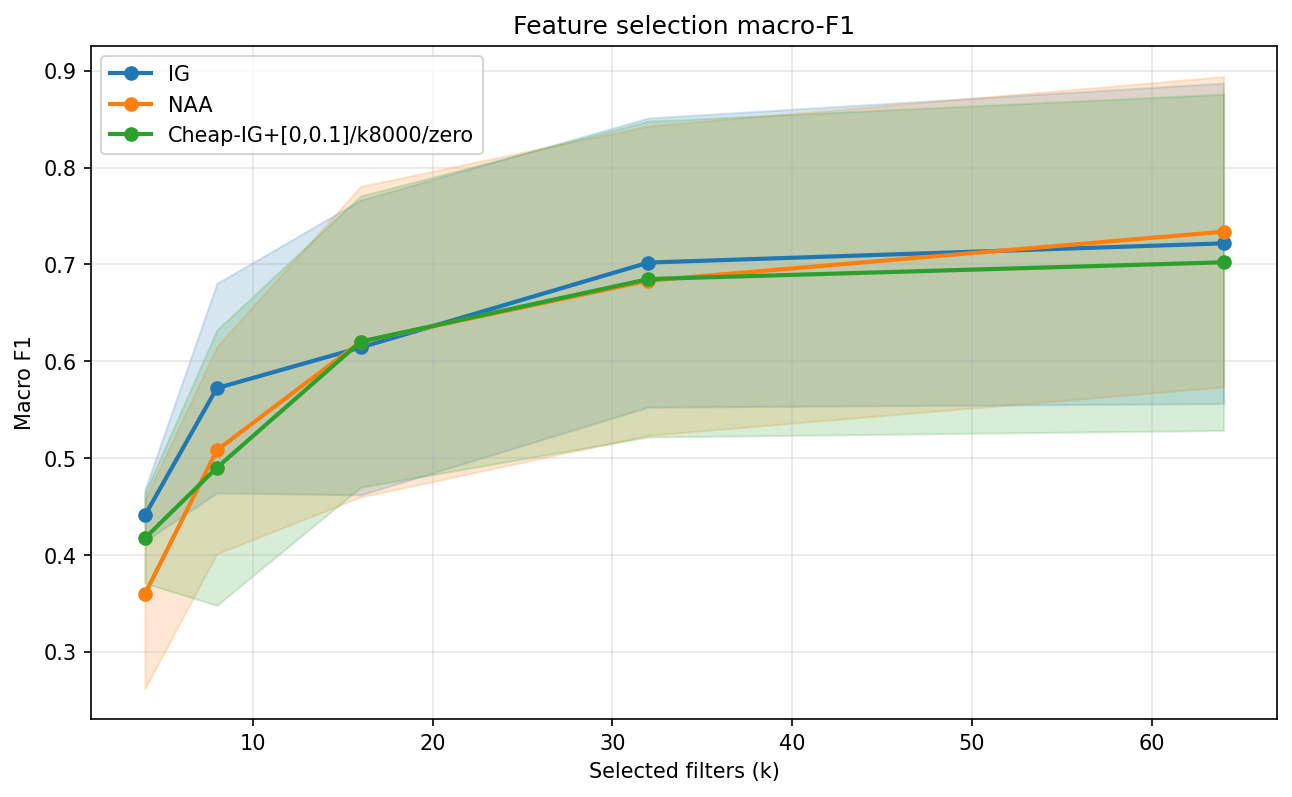

### Accuracy Heatmaps

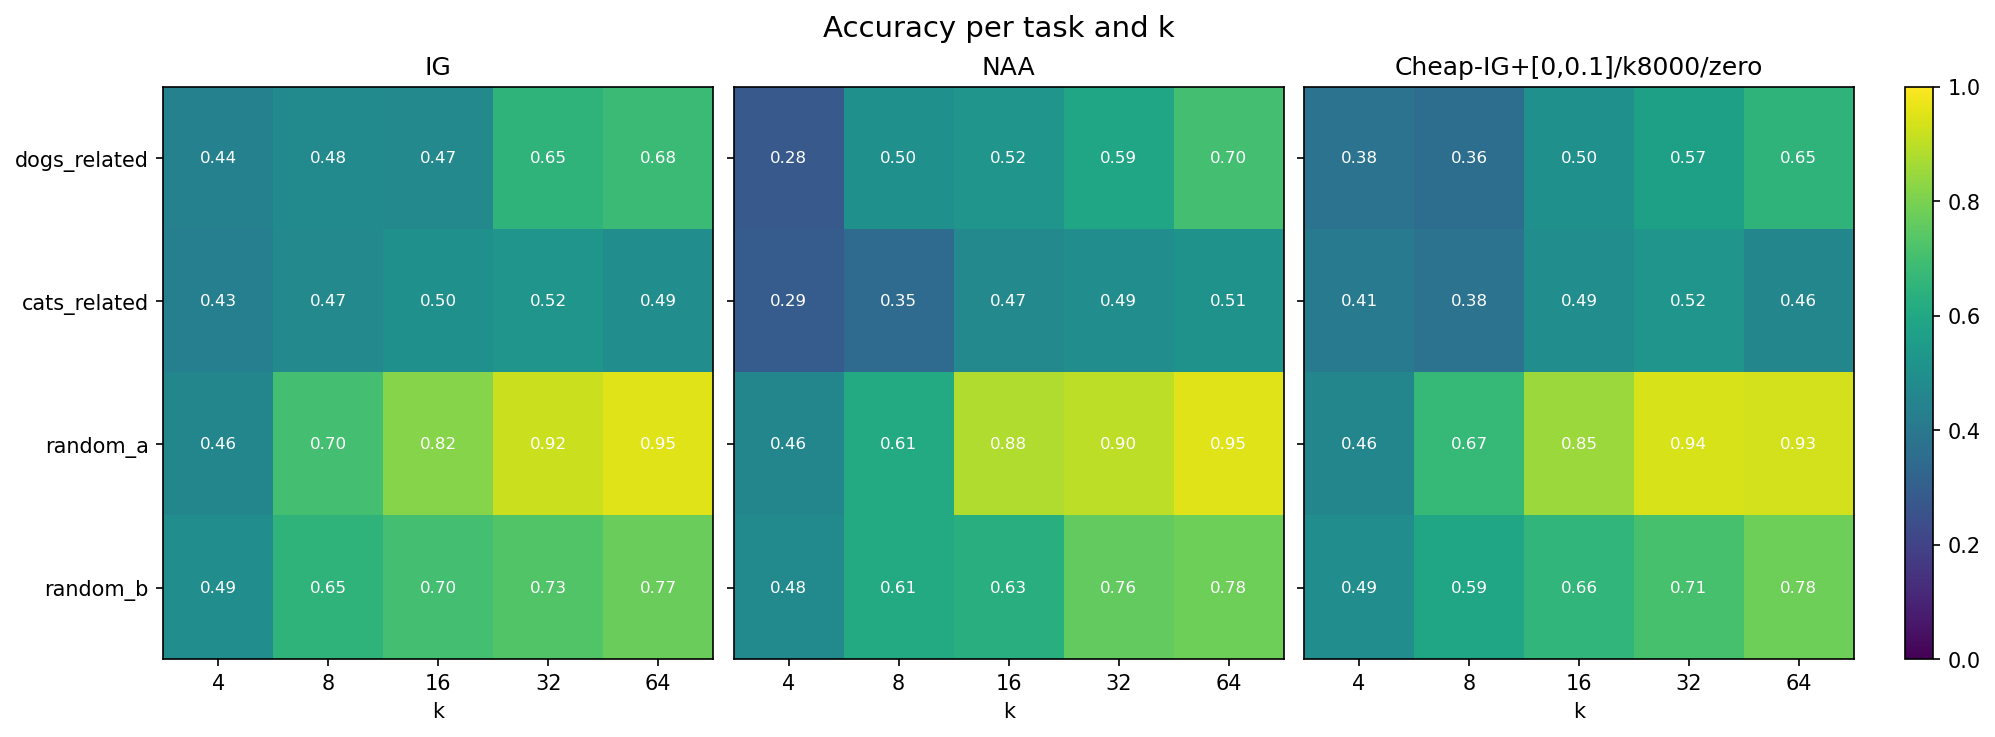

### Macro-F1 Heatmaps

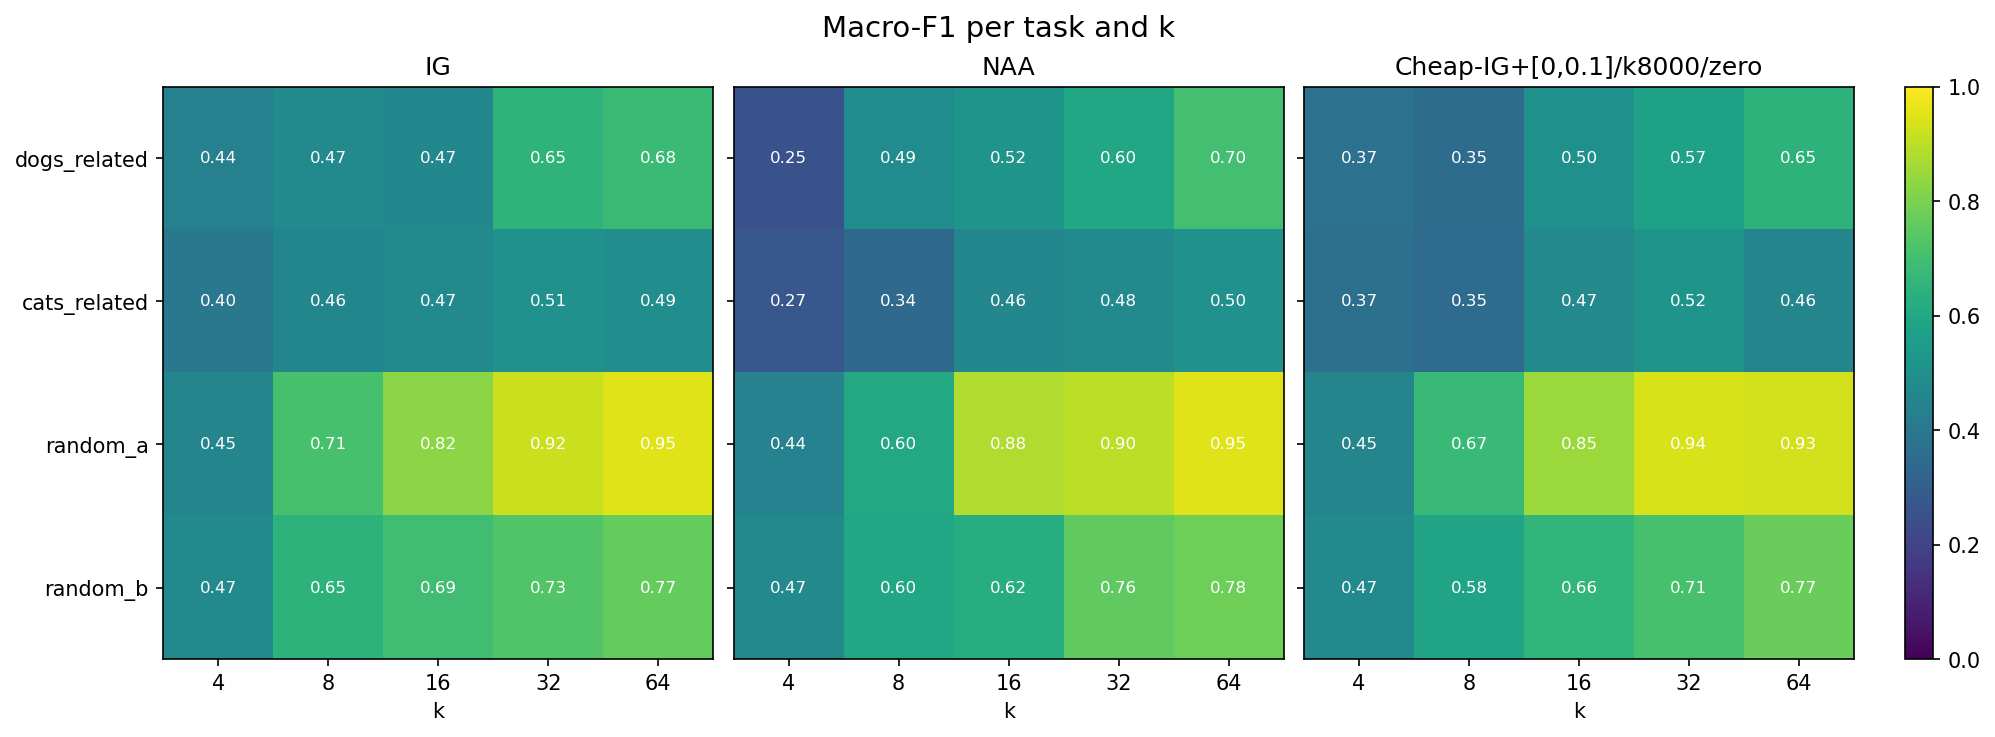

### Selected-Filter Overlap

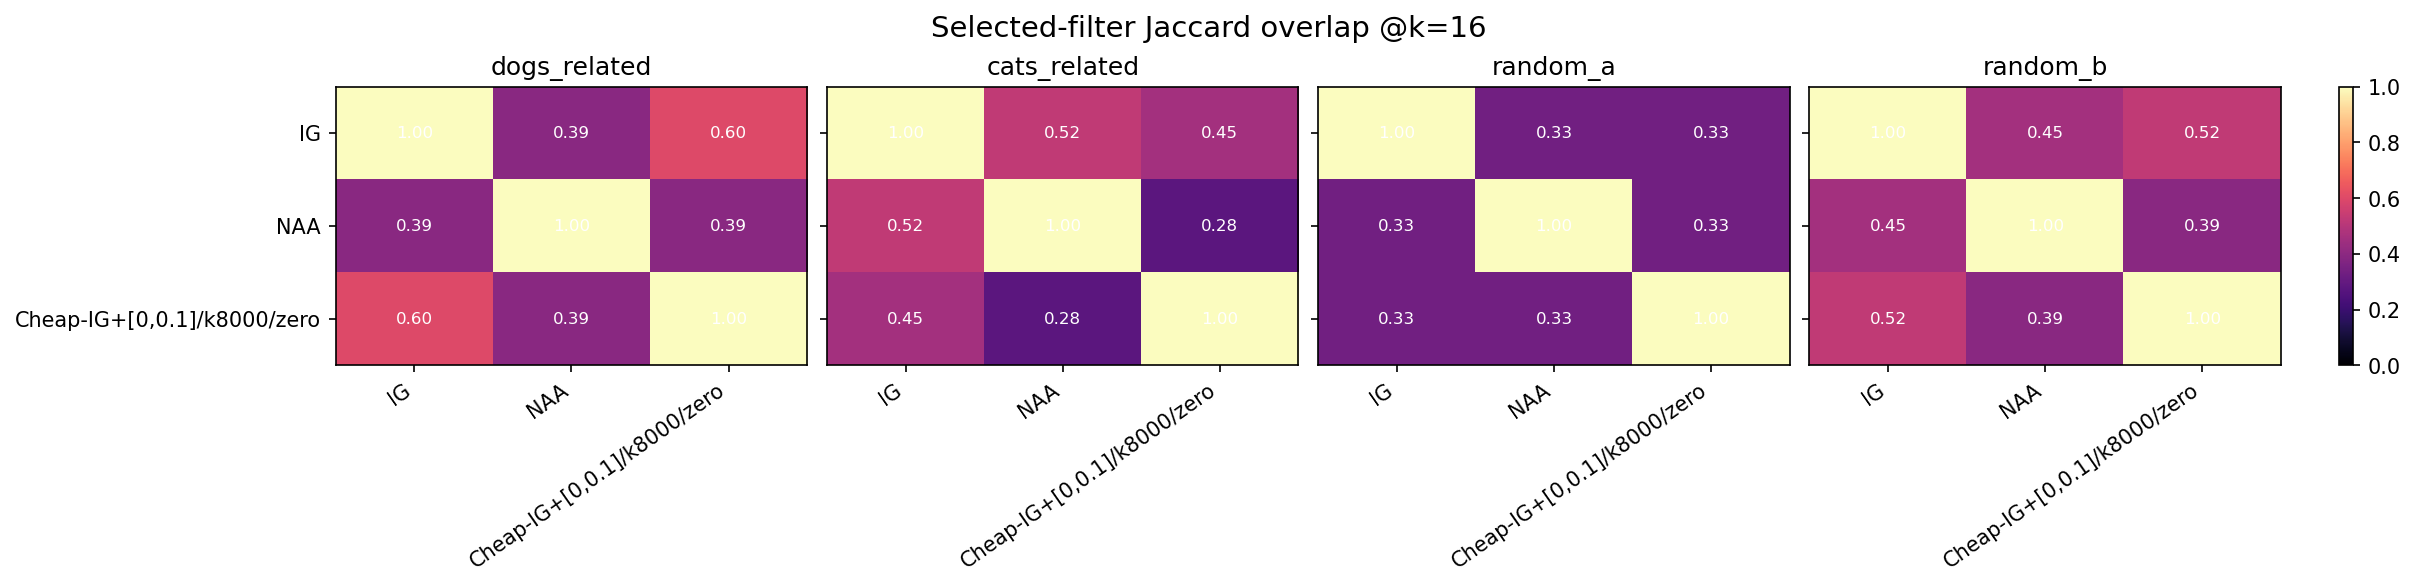

In [13]:
for key, title in [
    ("accuracy_curves", "Mean Accuracy Curves"),
    ("macro_f1_curves", "Mean Macro-F1 Curves"),
    ("accuracy_heatmaps", "Accuracy Heatmaps"),
    ("macro_f1_heatmaps", "Macro-F1 Heatmaps"),
    ("selected_overlap", "Selected-Filter Overlap"),
]:
    path = artifacts["figures"].get(key)
    if not path:
        continue
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))
